# CRNN: CNN + RNN + CTC

## The Complete Solution for Text Recognition

### CRNN Architecture Components:
1. **CNN Component**: Extracts spatial features from text images
2. **RNN Component**: Models sequential dependencies between characters
3. **CTC Loss**: Learns alignment between features and text without explicit segmentation

### Why This Combination Works:
- **CNN**: Handles spatial variations (fonts, sizes, noise)
- **RNN**: Captures sequence patterns (character order, language context)
- **CTC**: Enables variable-length output without manual alignment

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Complete CRNN Implementation
class CRNN(nn.Module):
    """Complete CRNN implementation for text recognition"""

    def __init__(self, img_height=32, img_width=100, num_classes=37,
                 hidden_size=256, num_layers=2):
        """
        Args:
            img_height (int): Height of input images
            img_width (int): Width of input images
            num_classes (int): Number of character classes (26 letters + 10 digits + blank)
            hidden_size (int): Hidden size for RNN layers
            num_layers (int): Number of RNN layers
        """
        super(CRNN, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # First conv block
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Second conv block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Third conv block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Fourth conv block
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),

            # Fifth conv block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Sixth conv block
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        )

        # Calculate the feature size after CNN
        # After all pooling: height = 32 // 2 // 2 // 2 // 2 = 2
        # Width remains the same due to (2,1) pooling
        self.feature_size = 512 * 2  # 512 channels * 2 height

        # RNN for sequence modeling
        self.rnn = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # Output layer
        self.output = nn.Linear(hidden_size * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input images of shape (batch_size, 1, height, width)

        Returns:
            torch.Tensor: Output probabilities of shape (batch_size, sequence_length, num_classes)
        """
        # CNN feature extraction
        features = self.cnn(x)  # (batch_size, 512, 2, width)

        # Reshape for RNN: (batch_size, width, features)
        batch_size, channels, height, width = features.size()
        features = features.view(batch_size, channels * height, width)
        features = features.permute(0, 2, 1)  # (batch_size, width, channels*height)

        # RNN sequence modeling
        rnn_out, _ = self.rnn(features)  # (batch_size, width, hidden_size*2)

        # Output layer
        output = self.output(rnn_out)  # (batch_size, width, num_classes)

        return output

# Create model instance
model = CRNN()
print("CRNN Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CRNN Architecture:
CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14

## Understanding Each Component

### 1. CNN Component (Feature Extractor)
- **Purpose**: Extract spatial features from text images
- **Architecture**: Multiple convolutional layers with batch normalization
- **Key Design**: Preserves width (sequence length) while reducing height
- **Output**: Feature maps representing character-level information

### 2. RNN Component (Sequence Modeler)
- **Purpose**: Model sequential dependencies between characters
- **Architecture**: Bidirectional LSTM layers
- **Key Design**: Bidirectional to use both past and future context
- **Output**: Sequence of hidden states with temporal information

### 3. CTC Loss (Alignment Learning)
- **Purpose**: Learn alignment between features and text automatically
- **Key Innovation**: No need for character-level annotations
- **Handles**: Variable-length sequences and character repetitions

## Variable Image Sizes → Variable Sequence Lengths

**Key Insight**: CRNN can handle different image widths, producing different sequence lengths!

This is crucial for handling variable-length text in real-world scenarios.

### How it Works:
1. **Wider Input** → **Longer Sequence** → **More Character Positions**
2. **CNN preserves width ratios** (reduces by constant factor)
3. **RNN processes variable-length sequences** naturally
4. **CTC handles alignment** for any sequence length
5. **This enables reading text of any length!**

### Examples:
- 60px wide → "Short text like 'CAT'" → ~15 time steps
- 100px wide → "Medium text like 'HELLO'" → ~25 time steps
- 140px wide → "Longer text like 'PYTHON'" → ~35 time steps
- 180px wide → "Very long text like 'MACHINE LEARNING'" → ~45 time steps

In [2]:
def demonstrate_variable_size_flow():
    """Show how CRNN handles different image sizes (different text lengths)"""

    # Create images of different sizes (simulating different text lengths)
    height = 32

    # Different widths for different text lengths
    sizes = [
        (60, "Short text like 'CAT'"),
        (100, "Medium text like 'HELLO'"),
        (140, "Longer text like 'PYTHON'"),
        (180, "Very long text like 'MACHINE LEARNING'")
    ]

    print("Variable Size Processing Results:")
    print("=" * 50)

    model.eval()
    with torch.no_grad():
        for i, (width, description) in enumerate(sizes):
            print(f"\n{i+1}. Processing {description}:")
            print(f"   Input size: (1, 1, {height}, {width})")

            # Create input image
            input_image = torch.randn(1, 1, height, width)

            # Forward pass through CNN
            cnn_features = model.cnn(input_image)
            print(f"   CNN output: {cnn_features.shape}")

            # Calculate sequence length after CNN
            sequence_length = cnn_features.shape[3]  # Width dimension
            print(f"   Sequence length: {sequence_length}")

            # Reshape for RNN
            batch_size, channels, h, w = cnn_features.size()
            features_reshaped = cnn_features.view(batch_size, channels * h, w)
            features_reshaped = features_reshaped.permute(0, 2, 1)

            # RNN processing
            rnn_out, _ = model.rnn(features_reshaped)

            # Final output
            final_output = model.output(rnn_out)
            print(f"   Final output: {final_output.shape}")
            print(f"   → Can predict up to {sequence_length} characters")

            # Show width reduction ratio
            reduction_ratio = width / sequence_length
            print(f"   Width reduction: {width} → {sequence_length} (ratio: {reduction_ratio:.1f}x)")

# Demonstrate variable size handling
demonstrate_variable_size_flow()

Variable Size Processing Results:

1. Processing Short text like 'CAT':
   Input size: (1, 1, 32, 60)
   CNN output: torch.Size([1, 512, 2, 15])
   Sequence length: 15
   Final output: torch.Size([1, 15, 37])
   → Can predict up to 15 characters
   Width reduction: 60 → 15 (ratio: 4.0x)

2. Processing Medium text like 'HELLO':
   Input size: (1, 1, 32, 100)
   CNN output: torch.Size([1, 512, 2, 25])
   Sequence length: 25
   Final output: torch.Size([1, 25, 37])
   → Can predict up to 25 characters
   Width reduction: 100 → 25 (ratio: 4.0x)

3. Processing Longer text like 'PYTHON':
   Input size: (1, 1, 32, 140)
   CNN output: torch.Size([1, 512, 2, 35])
   Sequence length: 35
   Final output: torch.Size([1, 35, 37])
   → Can predict up to 35 characters
   Width reduction: 140 → 35 (ratio: 4.0x)

4. Processing Very long text like 'MACHINE LEARNING':
   Input size: (1, 1, 32, 180)
   CNN output: torch.Size([1, 512, 2, 45])
   Sequence length: 45
   Final output: torch.Size([1, 45, 37])


## Complete CRNN Data Flow

Let's trace data through the entire CRNN architecture step by step:

### Data Flow Steps:
1. **Input Images**: Grayscale text images (batch_size, 1, height, width)
2. **CNN Features**: Spatial feature extraction with preserved width
3. **Reshape for RNN**: Convert to sequence format (batch_size, sequence_length, features)
4. **RNN Processing**: Bidirectional LSTM adds sequence context
5. **Final Output**: Character probabilities at each time step

### Key Points:
- **Width becomes sequence length** after CNN processing
- **Each time step** represents a column of features from the image
- **Bidirectional RNN** gives each position full sequence context
- **Final output** has character probabilities for each time step

In [3]:
def demonstrate_crnn_flow():
    """Show detailed data flow through CRNN architecture"""

    # Create sample input
    batch_size = 2
    height = 32
    width = 100

    # Simulate input images
    input_images = torch.randn(batch_size, 1, height, width)

    print("CRNN Data Flow Demonstration:")
    print("=" * 40)

    # Step 1: Input
    print(f"1. Input Images: {input_images.shape}")
    print(f"   - Batch size: {batch_size}")
    print(f"   - Channels: 1 (grayscale)")
    print(f"   - Height: {height} pixels")
    print(f"   - Width: {width} pixels")

    # Step 2: CNN Features
    model.eval()
    with torch.no_grad():
        # Extract CNN features
        cnn_features = model.cnn(input_images)
        print(f"\n2. CNN Features: {cnn_features.shape}")
        print(f"   - Channels: {cnn_features.shape[1]} (feature maps)")
        print(f"   - Height: {cnn_features.shape[2]} (reduced by pooling)")
        print(f"   - Width: {cnn_features.shape[3]} (preserved for sequence)")
        print(f"   - Width reduction: {width} → {cnn_features.shape[3]} pixels")

        # Step 3: Reshape for RNN
        batch_size, channels, height, width = cnn_features.size()
        features_reshaped = cnn_features.view(batch_size, channels * height, width)
        features_reshaped = features_reshaped.permute(0, 2, 1)
        print(f"\n3. Reshaped for RNN: {features_reshaped.shape}")
        print(f"   - Batch size: {features_reshaped.shape[0]}")
        print(f"   - Sequence length: {features_reshaped.shape[1]} (time steps)")
        print(f"   - Feature size: {features_reshaped.shape[2]}")
        print(f"   - Each time step represents a column of features")

        # Step 4: RNN Output
        rnn_out, _ = model.rnn(features_reshaped)
        print(f"\n4. RNN Output: {rnn_out.shape}")
        print(f"   - Hidden size: {rnn_out.shape[2] // 2} (bidirectional)")
        print(f"   - Total features: {rnn_out.shape[2]}")
        print(f"   - Each position has context from entire sequence")

        # Step 5: Final Output
        final_output = model.output(rnn_out)
        print(f"\n5. Final Output: {final_output.shape}")
        print(f"   - Sequence length: {final_output.shape[1]}")
        print(f"   - Number of classes: {final_output.shape[2]}")
        print(f"   - Each position predicts character probabilities")

        # Show probability distribution at first position
        first_pos_probs = F.softmax(final_output[0, 0], dim=0)
        print(f"\nExample: First position probabilities (first 10 classes):")
        for i in range(min(10, len(first_pos_probs))):
            print(f"   Class {i}: {first_pos_probs[i].item():.4f}")

# Demonstrate complete CRNN flow
demonstrate_crnn_flow()

CRNN Data Flow Demonstration:
1. Input Images: torch.Size([2, 1, 32, 100])
   - Batch size: 2
   - Channels: 1 (grayscale)
   - Height: 32 pixels
   - Width: 100 pixels

2. CNN Features: torch.Size([2, 512, 2, 25])
   - Channels: 512 (feature maps)
   - Height: 2 (reduced by pooling)
   - Width: 25 (preserved for sequence)
   - Width reduction: 100 → 25 pixels

3. Reshaped for RNN: torch.Size([2, 25, 1024])
   - Batch size: 2
   - Sequence length: 25 (time steps)
   - Feature size: 1024
   - Each time step represents a column of features

4. RNN Output: torch.Size([2, 25, 512])
   - Hidden size: 256 (bidirectional)
   - Total features: 512
   - Each position has context from entire sequence

5. Final Output: torch.Size([2, 25, 37])
   - Sequence length: 25
   - Number of classes: 37
   - Each position predicts character probabilities

Example: First position probabilities (first 10 classes):
   Class 0: 0.0278
   Class 1: 0.0261
   Class 2: 0.0277
   Class 3: 0.0277
   Class 4: 0.0275


## CTC Loss: The Key Innovation

### What is CTC (Connectionist Temporal Classification)?
CTC is a loss function that enables training sequence models without requiring aligned training data.

### Key Concepts:
1. **Blank Symbol**: Special symbol (usually index 0) representing "no character"
2. **Alignment**: Multiple ways to align output sequence with target
3. **Collapse**: Remove blanks and repeated characters to get final prediction

### Example:
```
Target: "CAT"
Possible alignments:
- "C-A-T" (where - is blank)
- "CC-AAT"
- "-C-A-T-"
- "CCA-ATT"
All collapse to "CAT"
```

## CNN Component Deep Dive

Let's analyze how the CNN component processes text images step by step:

### Key CNN Insights:
1. **Height Reduction**: Height is reduced for computational efficiency
2. **Width Preservation**: Width is preserved to maintain sequence information
3. **Feature Extraction**: Channels increase to capture more complex features
4. **Time Steps**: Each column represents features for one time step

In [4]:
def analyze_cnn_component():
    """Detailed analysis of CNN feature extraction"""

    # Create a simple CNN to analyze
    cnn_layers = [
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    ]

    # Test with sample input
    x = torch.randn(1, 1, 32, 100)  # (batch, channels, height, width)
    print(f"Input shape: {x.shape}")
    print(f"Input represents: 1 grayscale image, 32 pixels high, 100 pixels wide")

    # Track shape changes through layers
    for i, layer in enumerate(cnn_layers):
        x = layer(x)
        print(f"After layer {i+1} ({layer.__class__.__name__}): {x.shape}")

        if isinstance(layer, nn.Conv2d):
            print(f"  - Convolution extracts {x.shape[1]} feature maps")
        elif isinstance(layer, nn.MaxPool2d):
            print(f"  - Pooling reduces spatial dimensions")

    return x

# Run CNN analysis
cnn_features = analyze_cnn_component()

Input shape: torch.Size([1, 1, 32, 100])
Input represents: 1 grayscale image, 32 pixels high, 100 pixels wide
After layer 1 (Conv2d): torch.Size([1, 64, 32, 100])
  - Convolution extracts 64 feature maps
After layer 2 (ReLU): torch.Size([1, 64, 32, 100])
After layer 3 (MaxPool2d): torch.Size([1, 64, 16, 50])
  - Pooling reduces spatial dimensions
After layer 4 (Conv2d): torch.Size([1, 128, 16, 50])
  - Convolution extracts 128 feature maps
After layer 5 (ReLU): torch.Size([1, 128, 16, 50])
After layer 6 (MaxPool2d): torch.Size([1, 128, 8, 25])
  - Pooling reduces spatial dimensions


## RNN Component Deep Dive

The RNN component models sequential dependencies between character features:

### Bidirectional LSTM Benefits:
- **Forward Direction**: Sees past context (characters before current position)
- **Backward Direction**: Sees future context (characters after current position)
- **Combined**: Each position gets full context from both directions

### Sequence Context Example:
For text **'HELLO'**:
- Position 0 (H): sees nothing forward, everything backward
- Position 2 (L): sees 'HE' forward, 'LO' backward
- Position 4 (O): sees 'HELL' forward, nothing backward
- → Each position gets full context from both directions

In [5]:
def analyze_rnn_component():
    """Detailed analysis of RNN sequence modeling"""

    # Simulate CNN output as RNN input
    batch_size = 2
    sequence_length = 25  # Width after CNN processing
    feature_size = 512  # Features per time step

    # Create input sequence
    rnn_input = torch.randn(batch_size, sequence_length, feature_size)
    print(f"RNN Input shape: {rnn_input.shape}")
    print(f"  - {batch_size} samples in batch")
    print(f"  - {sequence_length} time steps (width positions)")
    print(f"  - {feature_size} features per time step")

    # Create bidirectional LSTM
    hidden_size = 256
    lstm = nn.LSTM(feature_size, hidden_size, batch_first=True, bidirectional=True)

    # Forward pass
    output, (hidden, cell) = lstm(rnn_input)

    print(f"\nRNN Output shape: {output.shape}")
    print(f"  - {output.shape[2]} features (256 forward + 256 backward)")
    print(f"  - Bidirectional: uses both past and future context")

    print(f"\nHidden state shape: {hidden.shape}")
    print(f"  - 2 directions × {batch_size} samples × {hidden_size} features")

    return output

# Run RNN analysis
rnn_output = analyze_rnn_component()

RNN Input shape: torch.Size([2, 25, 512])
  - 2 samples in batch
  - 25 time steps (width positions)
  - 512 features per time step

RNN Output shape: torch.Size([2, 25, 512])
  - 512 features (256 forward + 256 backward)
  - Bidirectional: uses both past and future context

Hidden state shape: torch.Size([2, 2, 256])
  - 2 directions × 2 samples × 256 features


## CTC (Connectionist Temporal Classification) Deep Dive

CTC is the key innovation that makes CRNN work without character-level segmentation:

### CTC Key Concepts:
1. **Blank Symbol**: Special symbol (usually index 0) representing "no character"
2. **Multiple Alignments**: Many ways to align output sequence with target text
3. **Collapse Rules**: Remove duplicates and blanks to get final prediction
4. **Automatic Learning**: No need for manual character-level annotations

### Why CTC is Powerful:
- ✓ No need for character-level segmentation
- ✓ Handles variable-length sequences
- ✓ Robust to timing variations
- ✓ End-to-end trainable
- ✓ Works with any sequence length ratio

In [6]:
def demonstrate_ctc_alignments():
    """Show multiple valid CTC alignments for same target"""

    # Character vocabulary
    chars = ['-'] + list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')  # Blank + 26 letters
    char_to_idx = {char: idx for idx, char in enumerate(chars)}
    idx_to_char = {idx: char for idx, char in enumerate(chars)}

    print(f"Vocabulary: {chars}")
    print(f"Blank symbol: '{chars[0]}' (index 0)")
    print(f"Total classes: {len(chars)}")

    # Example: Multiple valid alignments for "CAT"
    print("\nCTC Alignment Examples for target 'CAT':")

    alignments = [
        [0, 3, 0, 1, 0, 20, 0],      # -C-A-T-
        [3, 3, 1, 1, 20, 20, 0],     # CCAAT-
        [0, 0, 3, 1, 1, 20, 0],      # --CAT-
        [3, 0, 1, 0, 20, 0, 0],      # C-A-T--
    ]

    for i, alignment in enumerate(alignments):
        alignment_chars = [idx_to_char[idx] for idx in alignment]
        print(f"   Alignment {i+1}: {alignment_chars} → 'CAT'")

    return chars, char_to_idx, idx_to_char

# Demonstrate CTC alignments
chars, char_to_idx, idx_to_char = demonstrate_ctc_alignments()

Vocabulary: ['-', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Blank symbol: '-' (index 0)
Total classes: 27

CTC Alignment Examples for target 'CAT':
   Alignment 1: ['-', 'C', '-', 'A', '-', 'T', '-'] → 'CAT'
   Alignment 2: ['C', 'C', 'A', 'A', 'T', 'T', '-'] → 'CAT'
   Alignment 3: ['-', '-', 'C', 'A', 'A', 'T', '-'] → 'CAT'
   Alignment 4: ['C', '-', 'A', '-', 'T', '-', '-'] → 'CAT'


## CTC Decoding Process

Here's how CTC decoding works step-by-step:

### Decoding Steps:
1. **Raw Output**: Model produces sequence of character probabilities
2. **Argmax**: Take most likely character at each position
3. **Collapse**: Remove consecutive duplicates
4. **Remove Blanks**: Filter out blank symbols
5. **Final Text**: Remaining characters form the decoded text

In [7]:
def demonstrate_ctc_decoding():
    """Show step-by-step CTC decoding process"""

    # Example: decoding "HELLO"
    raw_output = [0, 8, 8, 5, 5, 5, 12, 12, 12, 15, 15, 0, 0]  # --HHEEEELLLOOO--
    raw_chars = [idx_to_char[idx] for idx in raw_output]

    print("CTC Decoding Process:")
    print(f"Raw output: {raw_chars}")
    print(f"Raw indices: {raw_output}")

    # Step 1: Remove consecutive duplicates
    step1 = []
    prev = None
    for idx in raw_output:
        if idx != prev:
            step1.append(idx)
        prev = idx
    step1_chars = [idx_to_char[idx] for idx in step1]
    print(f"After collapse: {step1_chars}")

    # Step 2: Remove blanks
    step2 = [idx for idx in step1 if idx != 0]
    step2_chars = [idx_to_char[idx] for idx in step2]
    final_text = ''.join(step2_chars)
    print(f"Remove blanks: {step2_chars}")
    print(f"Final text: '{final_text}'")

    return final_text

# Demonstrate CTC decoding
decoded_text = demonstrate_ctc_decoding()

CTC Decoding Process:
Raw output: ['-', 'H', 'H', 'E', 'E', 'E', 'L', 'L', 'L', 'O', 'O', '-', '-']
Raw indices: [0, 8, 8, 5, 5, 5, 12, 12, 12, 15, 15, 0, 0]
After collapse: ['-', 'H', 'E', 'L', 'O', '-']
Remove blanks: ['H', 'E', 'L', 'O']
Final text: 'HELO'


## CTC Loss Computation

CTC loss computation involves:

### Loss Components:
- **Model Outputs**: Log probabilities for each character class at each time step
- **Target Text**: Ground truth text (e.g., "CAT", "DOG")
- **Input Lengths**: Length of model output sequences
- **Target Lengths**: Length of target texts

### CTC Loss Function:
- Sums probabilities over all valid alignments
- Uses dynamic programming for efficient computation
- Automatically learns best alignment strategy

In [8]:
def demonstrate_ctc_loss():
    """Show CTC loss computation"""

    batch_size = 2
    sequence_length = 8
    num_classes = len(chars)

    # Create model outputs (before softmax)
    logits = torch.randn(batch_size, sequence_length, num_classes)
    log_probs = F.log_softmax(logits, dim=2)

    # Targets: "CAT" and "DOG"
    targets = torch.tensor([
        [char_to_idx['C'], char_to_idx['A'], char_to_idx['T']],
        [char_to_idx['D'], char_to_idx['O'], char_to_idx['G']]
    ])

    # Flatten targets for CTC
    targets_flat = targets.view(-1)
    input_lengths = torch.tensor([sequence_length] * batch_size)
    target_lengths = torch.tensor([3, 3])

    # Compute CTC loss
    ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean')
    log_probs_ctc = log_probs.transpose(0, 1)  # (T, N, C)

    loss = ctc_loss_fn(log_probs_ctc, targets_flat, input_lengths, target_lengths)

    print("CTC Loss Computation:")
    print(f"Batch size: {batch_size}")
    print(f"Sequence length: {sequence_length}")
    print(f"Number of classes: {num_classes}")
    print(f"Targets: {['CAT', 'DOG']}")
    print(f"CTC Loss: {loss.item():.4f}")

    return loss

# Demonstrate CTC loss
ctc_loss = demonstrate_ctc_loss()

CTC Loss Computation:
Batch size: 2
Sequence length: 8
Number of classes: 27
Targets: ['CAT', 'DOG']
CTC Loss: 6.9375


## CTC Duplicate Character Handling - The Key to Accurate Text Recognition

### The Problem You Might Have Noticed
In some CTC examples, you might see **"HELLO" → "HELO"** where one 'L' is missing. This happens because:

1. **CTC removes consecutive duplicates** during decoding
2. **Poorly trained models** don't learn to separate duplicates properly
3. **Missing blank symbols** between duplicate characters

### The Solution: Blank Symbols Separate Duplicates

**Key Insight**: CTC uses **blank symbols** (usually `-` or index 0) to separate duplicate characters.

#### ✅ **Correct Way** (Well-trained model):
```
Target: "HELLO"
Alignment: [H, E, L, -, L, O]  # <- Blank (-) separates the two L's
Decoding: Remove consecutive duplicates → [H, E, L, -, L, O]
         Remove blanks → [H, E, L, L, O]
         Final: "HELLO" ✅
```

#### ❌ **Wrong Way** (Poorly trained model):
```
Target: "HELLO"  
Alignment: [H, E, L, L, O]     # <- No blank between L's
Decoding: Remove consecutive duplicates → [H, E, L, O]  # L's collapsed!
         Remove blanks → [H, E, L, O]
         Final: "HELO" ❌
```

### Why This Matters
- **Without blank**: `L-L` → becomes `L` (collapsed)
- **With blank**: `L-<blank>-L` → becomes `L-L` (preserved)

The model must **learn when and where** to predict blank symbols to separate duplicates!

In [9]:
# CTC Duplicate Character Handling Demonstration
class CTCDuplicateExplainer:
    """Explains how CTC handles duplicate characters"""

    def __init__(self, vocab):
        self.vocab = vocab
        self.blank_idx = 0
        self.char_to_idx = {char: idx for idx, char in enumerate(vocab)}
        self.idx_to_char = {idx: char for idx, char in enumerate(vocab)}

    def decode_alignment(self, alignment):
        """Decode CTC alignment to text using standard CTC rules"""
        # Step 1: Remove consecutive duplicates
        collapsed = []
        prev_idx = None
        for idx in alignment:
            if idx != prev_idx:
                collapsed.append(idx)
            prev_idx = idx

        # Step 2: Remove blanks
        filtered = [idx for idx in collapsed if idx != self.blank_idx]

        # Step 3: Convert to text
        text = ''.join([self.idx_to_char[idx] for idx in filtered])
        return text

    def demonstrate_duplicates(self):
        """Show how different alignments handle duplicates"""
        print("CTC Duplicate Character Handling Examples")
        print("=" * 50)

        # Example 1: HELLO with correct alignment
        print("\n1. Target: 'HELLO' (has duplicate L)")
        correct_alignment = [8, 5, 12, 0, 12, 15]  # H-E-L-blank-L-O
        chars = [self.idx_to_char[idx] for idx in correct_alignment]
        decoded = self.decode_alignment(correct_alignment)
        print(f"   ✅ Correct alignment: {chars}")
        print(f"   ✅ Decoded result: '{decoded}'")
        print(f"   ✅ Blank symbol separates duplicate L's!")

        # Example 2: HELLO with wrong alignment
        wrong_alignment = [8, 5, 12, 12, 15]  # H-E-L-L-O (no blank)
        chars = [self.idx_to_char[idx] for idx in wrong_alignment]
        decoded = self.decode_alignment(wrong_alignment)
        print(f"\n   ❌ Wrong alignment: {chars}")
        print(f"   ❌ Decoded result: '{decoded}'")
        print(f"   ❌ Consecutive L's collapsed into one!")

        # More examples
        examples = [
            ("BOOK", [2, 15, 0, 15, 11]),  # B-O-blank-O-K
            ("COFFEE", [3, 15, 6, 0, 6, 5, 0, 5]),  # C-O-F-blank-F-E-blank-E
            ("BANANA", [2, 1, 14, 1, 14, 1])  # B-A-N-A-N-A (no duplicates need blanks)
        ]

        print("\n2. More duplicate examples:")
        for target, alignment in examples:
            chars = [self.idx_to_char[idx] for idx in alignment]
            decoded = self.decode_alignment(alignment)
            status = "✅" if decoded == target else "❌"
            print(f"   {status} Target: '{target}' → Alignment: {chars} → Result: '{decoded}'")

        print("\n3. Key Takeaways:")
        print("   • Blank symbols (index 0) separate duplicate characters")
        print("   • Well-trained models learn to predict blanks at the right time")
        print("   • Poor training → missing blanks → lost duplicate characters")
        print("   • Solution: More training data with duplicate examples!")

# Create vocabulary and demonstrate
vocab = ['-'] + list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')  # Blank + 26 letters
explainer = CTCDuplicateExplainer(vocab)
explainer.demonstrate_duplicates()

CTC Duplicate Character Handling Examples

1. Target: 'HELLO' (has duplicate L)
   ✅ Correct alignment: ['H', 'E', 'L', '-', 'L', 'O']
   ✅ Decoded result: 'HELLO'
   ✅ Blank symbol separates duplicate L's!

   ❌ Wrong alignment: ['H', 'E', 'L', 'L', 'O']
   ❌ Decoded result: 'HELO'
   ❌ Consecutive L's collapsed into one!

2. More duplicate examples:
   ✅ Target: 'BOOK' → Alignment: ['B', 'O', '-', 'O', 'K'] → Result: 'BOOK'
   ✅ Target: 'COFFEE' → Alignment: ['C', 'O', 'F', '-', 'F', 'E', '-', 'E'] → Result: 'COFFEE'
   ✅ Target: 'BANANA' → Alignment: ['B', 'A', 'N', 'A', 'N', 'A'] → Result: 'BANANA'

3. Key Takeaways:
   • Blank symbols (index 0) separate duplicate characters
   • Well-trained models learn to predict blanks at the right time
   • Poor training → missing blanks → lost duplicate characters
   • Solution: More training data with duplicate examples!


## Complete CRNN Training Pipeline - Step by Step

Now let's build a complete training pipeline that properly handles duplicate characters!

### Training Pipeline Overview:
1. **Dataset Creation**: Generate synthetic text images with duplicates
2. **Model Setup**: Create CRNN architecture
3. **Training Loop**: Train with CTC loss
4. **Evaluation**: Test on duplicate-containing words
5. **Visualization**: Show predictions and improvements

### Key Training Tips for Duplicate Handling:
- Include many examples with duplicate characters
- Use longer training sequences
- Monitor accuracy specifically on duplicate-containing words
- Ensure balanced vocabulary in training data

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import random
import string
from typing import List, Tuple, Optional

class SyntheticTextDataset(Dataset):
    """Synthetic text dataset generator for CRNN training."""

    def __init__(
        self,
        vocab: str = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",
        img_height: int = 32,
        min_width: int = 60,
        max_width: int = 200,
        min_text_length: int = 3,
        max_text_length: int = 12,
        dataset_size: int = 10000,
        duplicate_prob: float = 0.3
    ):
        self.vocab = vocab
        self.img_height = img_height
        self.min_width = min_width
        self.max_width = max_width
        self.min_text_length = min_text_length
        self.max_text_length = max_text_length
        self.dataset_size = dataset_size
        self.duplicate_prob = duplicate_prob

        # Character mappings (blank symbol at index 0)
        self.chars = ['-'] + list(vocab)  # '-' is blank symbol
        self.char_to_idx = {char: idx for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx: char for idx, char in enumerate(self.chars)}
        self.num_classes = len(self.chars)

        print(f"Dataset created with {self.num_classes} classes")
        print(f"Vocabulary: {self.vocab}")

    def _generate_text_with_duplicates(self) -> str:
        """Generate text with controlled duplicate character probability."""
        length = random.randint(self.min_text_length, self.max_text_length)

        if random.random() < self.duplicate_prob:
            # Generate text with at least one duplicate
            text = ''.join(random.choices(self.vocab, k=length))
            # Ensure at least one duplicate by replacing a character
            if length > 1:
                pos = random.randint(0, length - 2)
                char = text[pos]
                # Place same character at adjacent position
                text = text[:pos+1] + char + text[pos+1:]
        else:
            # Generate text without consecutive duplicates
            text = ""
            prev_char = None
            for _ in range(length):
                char = random.choice(self.vocab)
                while char == prev_char:
                    char = random.choice(self.vocab)
                text += char
                prev_char = char

        return text

    def _create_text_image(self, text: str, width: int) -> np.ndarray:
        """Create image from text with realistic variations."""
        # Create PIL image
        img = Image.new('RGB', (width, self.img_height), color='white')
        draw = ImageDraw.Draw(img)

        # Use default font
        try:
            font = ImageFont.load_default()
        except:
            font = None

        # Calculate text position for centering
        if font:
            bbox = draw.textbbox((0, 0), text, font=font)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        else:
            text_width = len(text) * 8
            text_height = 12

        # Center text
        x_offset = max(0, (width - text_width) // 2)
        y_offset = (self.img_height - text_height) // 2

        # Draw text
        draw.text((x_offset, y_offset), text, fill='black', font=font)

        # Convert to grayscale array
        img_array = np.array(img)
        if len(img_array.shape) == 3:
            img_array = np.mean(img_array, axis=2)

        # Add noise
        noise = np.random.normal(0, 10, img_array.shape)
        img_array = np.clip(img_array + noise, 0, 255)

        # Normalize to [0, 1]
        img_array = img_array.astype(np.float32) / 255.0

        return img_array

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, int, int]:
        # Generate random text
        text = self._generate_text_with_duplicates()

        # Generate random width
        width = random.randint(self.min_width, self.max_width)

        # Create image
        img_array = self._create_text_image(text, width)

        # Convert to tensor
        img_tensor = torch.from_numpy(img_array).unsqueeze(0)  # Add channel dim

        # Convert text to indices (excluding blank)
        target_indices = [self.char_to_idx[char] for char in text]
        target_tensor = torch.tensor(target_indices, dtype=torch.long)

        # Calculate input length after CNN processing (width reduced by 4x)
        input_length = width // 4
        target_length = len(text)

        return img_tensor, target_tensor, input_length, target_length

# Create dataset instance
dataset = SyntheticTextDataset(
    dataset_size=5000,
    duplicate_prob=0.4  # Higher probability for duplicate examples
)

print(f"\nDataset created with {len(dataset)} samples")
print(f"Vocabulary size: {dataset.num_classes} (including blank)")

Dataset created with 37 classes
Vocabulary: ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789

Dataset created with 5000 samples
Vocabulary size: 37 (including blank)


Sample Dataset Images:
Sample 1: 'P8OUB12NHG' (len=10, width=191, seq_len=47)
Sample 2: '4I111' (len=5, width=117, seq_len=29)
Sample 3: 'JVJ1VE2EC' (len=9, width=108, seq_len=27)
Sample 4: 'QC9MH0D9DUR' (len=11, width=104, seq_len=26)
Sample 5: 'Q298O' (len=5, width=159, seq_len=39)
Sample 6: '3XPSTPAAPKEFY' (len=13, width=153, seq_len=38)
Sample 7: 'LRJP1N8EX0' (len=10, width=106, seq_len=26)
Sample 8: 'CVM' (len=3, width=67, seq_len=16)


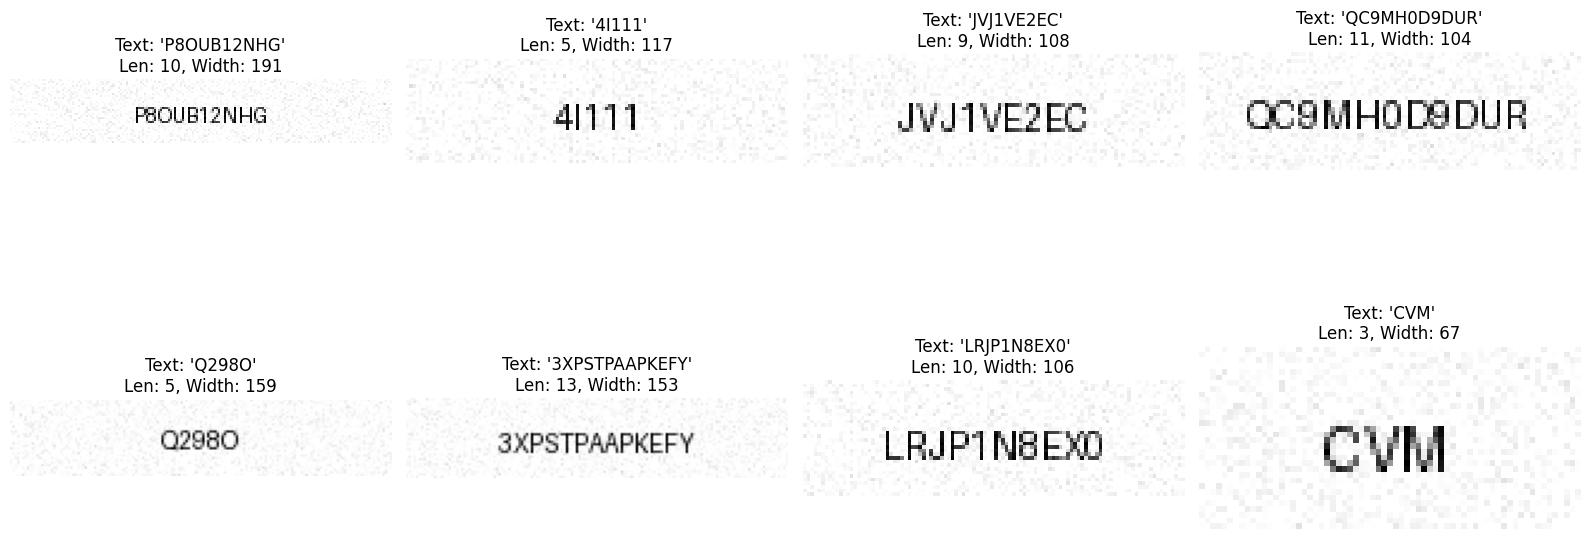


Duplicate Statistics (from 100 samples):
Samples with consecutive duplicates: 37/100 (37.0%)


In [11]:
# Visualize sample images from the dataset
def visualize_dataset_samples(dataset, num_samples=8):
    """Visualize sample images from the synthetic dataset."""

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    print("Sample Dataset Images:")
    print("=" * 50)

    for i in range(num_samples):
        # Get random sample
        img_tensor, target_tensor, input_len, target_len = dataset[i]

        # Convert target back to text
        text = ''.join([dataset.idx_to_char[idx.item()] for idx in target_tensor])

        # Display image
        img_array = img_tensor.squeeze().numpy()
        axes[i].imshow(img_array, cmap='gray')
        axes[i].set_title(f"Text: '{text}'\nLen: {target_len}, Width: {img_array.shape[1]}")
        axes[i].axis('off')

        # Print details
        print(f"Sample {i+1}: '{text}' (len={target_len}, width={img_array.shape[1]}, seq_len={input_len})")

    plt.tight_layout()
    plt.show()

    # Show duplicate statistics
    duplicate_count = 0
    total_samples = 100

    for i in range(total_samples):
        _, target_tensor, _, _ = dataset[i]
        text = ''.join([dataset.idx_to_char[idx.item()] for idx in target_tensor])

        # Check for duplicates
        has_duplicates = any(text[j] == text[j+1] for j in range(len(text)-1))
        if has_duplicates:
            duplicate_count += 1

    print(f"\nDuplicate Statistics (from {total_samples} samples):")
    print(f"Samples with consecutive duplicates: {duplicate_count}/{total_samples} ({duplicate_count/total_samples*100:.1f}%)")

# Visualize samples
visualize_dataset_samples(dataset)

In [12]:
class CRNNTrainer:
    """Complete CRNN training pipeline with CTC loss."""

    def __init__(self, model, dataset, device='cpu'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device

        # Loss and optimizer
        self.criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
        self.optimizer = optim.Adam(model.parameters(), lr=0.001)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.5)

        # Training history
        self.train_losses = []
        self.train_accuracies = []

    def collate_fn(self, batch):
        """Custom collate function for variable-length sequences."""
        # Sort batch by input length (descending)
        batch.sort(key=lambda x: x[2], reverse=True)

        images, targets, input_lengths, target_lengths = zip(*batch)

        # Pad images to same width (largest in batch)
        max_width = max(img.shape[2] for img in images)
        padded_images = []

        for img in images:
            _, h, w = img.shape
            if w < max_width:
                # Pad with zeros (white background)
                pad = torch.zeros(1, h, max_width - w)
                img = torch.cat([img, pad], dim=2)
            padded_images.append(img)

        # Stack images
        images = torch.stack(padded_images)

        # Concatenate targets
        targets = torch.cat(targets)

        # Convert lengths to tensors
        input_lengths = torch.tensor(input_lengths)
        target_lengths = torch.tensor(target_lengths)

        return images, targets, input_lengths, target_lengths

    def decode_predictions(self, predictions):
        """Decode CTC predictions to text."""
        batch_size, seq_len, num_classes = predictions.shape
        decoded_texts = []

        for i in range(batch_size):
            # Get most likely character at each position
            pred_indices = torch.argmax(predictions[i], dim=1)

            # Remove consecutive duplicates
            collapsed = []
            prev_idx = None
            for idx in pred_indices:
                if idx != prev_idx:
                    collapsed.append(idx.item())
                prev_idx = idx

            # Remove blanks
            filtered = [idx for idx in collapsed if idx != 0]

            # Convert to text
            text = ''.join([self.dataset.idx_to_char[idx] for idx in filtered])
            decoded_texts.append(text)

        return decoded_texts

    def calculate_accuracy(self, predictions, targets, target_lengths):
        """Calculate character-level accuracy."""
        decoded_texts = self.decode_predictions(predictions)

        # Convert targets back to text
        target_texts = []
        start_idx = 0
        for length in target_lengths:
            target_indices = targets[start_idx:start_idx + length]
            text = ''.join([self.dataset.idx_to_char[idx.item()] for idx in target_indices])
            target_texts.append(text)
            start_idx += length

        # Calculate accuracy
        correct = sum(1 for pred, target in zip(decoded_texts, target_texts) if pred == target)
        total = len(target_texts)

        return correct / total, decoded_texts, target_texts

    def train_epoch(self, dataloader):
        """Train one epoch."""
        self.model.train()
        total_loss = 0
        total_accuracy = 0
        num_batches = 0

        for batch_idx, (images, targets, input_lengths, target_lengths) in enumerate(dataloader):
            # Move to device
            images = images.to(self.device)
            targets = targets.to(self.device)
            input_lengths = input_lengths.to(self.device)
            target_lengths = target_lengths.to(self.device)

            # Forward pass
            outputs = self.model(images)  # (batch_size, seq_len, num_classes)

            # Prepare for CTC loss
            log_probs = F.log_softmax(outputs, dim=2)
            log_probs = log_probs.transpose(0, 1)  # (seq_len, batch_size, num_classes)

            # Calculate loss
            loss = self.criterion(log_probs, targets, input_lengths, target_lengths)

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)

            self.optimizer.step()

            # Calculate accuracy
            with torch.no_grad():
                accuracy, _, _ = self.calculate_accuracy(outputs, targets, target_lengths)

            total_loss += loss.item()
            total_accuracy += accuracy
            num_batches += 1

            if batch_idx % 10 == 0:
                print(f"Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}, Acc: {accuracy:.3f}")

        avg_loss = total_loss / num_batches
        avg_accuracy = total_accuracy / num_batches

        return avg_loss, avg_accuracy

    def train(self, num_epochs=20, batch_size=32):
        """Complete training loop."""
        # Create data loader
        dataloader = DataLoader(
            self.dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=self.collate_fn
        )

        print(f"Starting training for {num_epochs} epochs...")
        print(f"Dataset size: {len(self.dataset)}, Batch size: {batch_size}")

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print("-" * 50)

            # Train epoch
            avg_loss, avg_accuracy = self.train_epoch(dataloader)

            # Update scheduler
            self.scheduler.step()

            # Store history
            self.train_losses.append(avg_loss)
            self.train_accuracies.append(avg_accuracy)

            print(f"Epoch {epoch+1} Summary:")
            print(f"Average Loss: {avg_loss:.4f}")
            print(f"Average Accuracy: {avg_accuracy:.3f}")
            print(f"Learning Rate: {self.scheduler.get_last_lr()[0]:.6f}")

        print("\nTraining completed!")

    def test_on_samples(self, num_samples=8):
        """Test model on sample data and show predictions."""
        self.model.eval()

        print("\nTesting Model on Sample Data:")
        print("=" * 60)

        correct_predictions = 0

        with torch.no_grad():
            for i in range(num_samples):
                # Get sample
                img_tensor, target_tensor, input_len, target_len = self.dataset[i]

                # Convert target to text
                target_text = ''.join([self.dataset.idx_to_char[idx.item()] for idx in target_tensor])

                # Predict
                img_batch = img_tensor.unsqueeze(0).to(self.device)
                outputs = self.model(img_batch)

                # Decode prediction
                predicted_texts = self.decode_predictions(outputs)
                predicted_text = predicted_texts[0]

                # Check accuracy
                is_correct = predicted_text == target_text
                if is_correct:
                    correct_predictions += 1

                status = "✅" if is_correct else "❌"
                print(f"{status} Sample {i+1}: Target='{target_text}' → Predicted='{predicted_text}'")

        accuracy = correct_predictions / num_samples
        print(f"\nSample Test Accuracy: {correct_predictions}/{num_samples} ({accuracy:.1%})")

        return accuracy

# Create model and trainer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create CRNN model with correct number of classes
model = CRNN(num_classes=dataset.num_classes)
print(f"\nCRNN Model created with {dataset.num_classes} classes")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Create trainer
trainer = CRNNTrainer(model, dataset, device)

Using device: cuda

CRNN Model created with 37 classes
Model parameters: 8,724,645


In [13]:
# Train the model
print("Starting CRNN Training with CTC Loss")
print("=" * 50)

# Test before training
print("Performance before training:")
pre_training_accuracy = trainer.test_on_samples(num_samples=10)

# Train the model
trainer.train(num_epochs=15, batch_size=16)

# Test after training
print("\nPerformance after training:")
post_training_accuracy = trainer.test_on_samples(num_samples=10)

print(f"\nTraining Results Summary:")
print(f"Pre-training accuracy: {pre_training_accuracy:.1%}")
print(f"Post-training accuracy: {post_training_accuracy:.1%}")
print(f"Improvement: {post_training_accuracy - pre_training_accuracy:.1%}")

Starting CRNN Training with CTC Loss
Performance before training:

Testing Model on Sample Data:
❌ Sample 1: Target='00H9SV5PIAA4J' → Predicted='Q5'
❌ Sample 2: Target='RH0RT6GLE9' → Predicted='Q5'
❌ Sample 3: Target='OAXS' → Predicted='Q5'
❌ Sample 4: Target='QNO' → Predicted='Q5'
❌ Sample 5: Target='J79278RL' → Predicted='Q5'
❌ Sample 6: Target='XYJLEL6' → Predicted='Q5'
❌ Sample 7: Target='9L7MK2' → Predicted='Q5'
❌ Sample 8: Target='7OOD23' → Predicted='Q5'
❌ Sample 9: Target='TLQ' → Predicted='Q5'
❌ Sample 10: Target='LXBR3ZP' → Predicted='Q5'

Sample Test Accuracy: 0/10 (0.0%)
Starting training for 15 epochs...
Dataset size: 5000, Batch size: 16

Epoch 1/15
--------------------------------------------------
Batch 0/313, Loss: 13.9347, Acc: 0.000
Batch 10/313, Loss: 4.1436, Acc: 0.000
Batch 20/313, Loss: 4.0547, Acc: 0.000
Batch 30/313, Loss: 3.8315, Acc: 0.000
Batch 40/313, Loss: 3.8534, Acc: 0.000
Batch 50/313, Loss: 3.9936, Acc: 0.000
Batch 60/313, Loss: 3.9524, Acc: 0.000
Batc

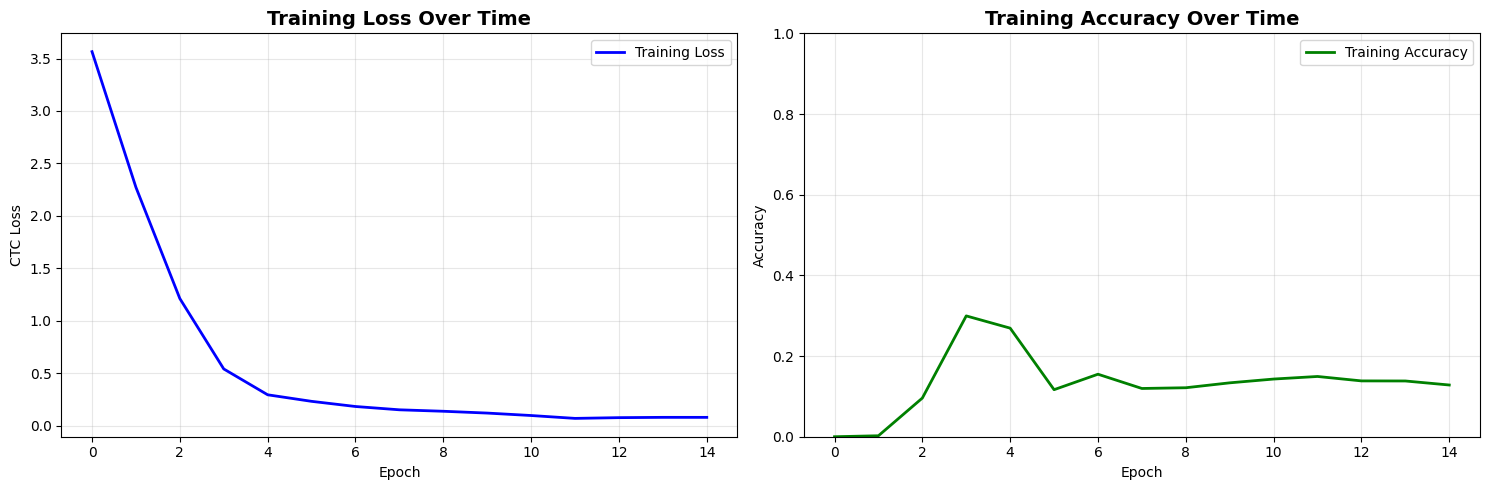

Final Training Loss: 0.0809
Final Training Accuracy: 0.128
Best Training Accuracy: 0.300


In [14]:
# Visualize training progress
def plot_training_history(trainer):
    """Plot training loss and accuracy curves."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(trainer.train_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('CTC Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot accuracy
    ax2.plot(trainer.train_accuracies, 'g-', linewidth=2, label='Training Accuracy')
    ax2.set_title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Print final metrics
    if trainer.train_losses:
        print(f"Final Training Loss: {trainer.train_losses[-1]:.4f}")
        print(f"Final Training Accuracy: {trainer.train_accuracies[-1]:.3f}")
        print(f"Best Training Accuracy: {max(trainer.train_accuracies):.3f}")

# Plot training history
plot_training_history(trainer)

In [15]:
# Test specifically on words with duplicate characters
def test_duplicate_handling(trainer, dataset):
    """Test model specifically on words with duplicate characters."""

    print("Testing Duplicate Character Handling")
    print("=" * 50)

    # Create test cases with known duplicates
    duplicate_test_words = [
        "HELLO", "BOOK", "COFFEE", "LETTER", "BALLOON",
        "APPLE", "DOOR", "KEEP", "GOOD", "MOON"
    ]

    correct_duplicates = 0
    total_duplicates = len(duplicate_test_words)

    trainer.model.eval()
    with torch.no_grad():
        for word in duplicate_test_words:
            # Create image for this word
            width = max(100, len(word) * 15)
            img_array = dataset._create_text_image(word, width)
            img_tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0)

            # Predict
            img_batch = img_tensor.to(trainer.device)
            outputs = trainer.model(img_batch)

            # Decode prediction
            predicted_texts = trainer.decode_predictions(outputs)
            predicted_word = predicted_texts[0]

            # Check if prediction is correct
            is_correct = predicted_word == word
            if is_correct:
                correct_duplicates += 1

            status = "✅" if is_correct else "❌"
            print(f"{status} Target: '{word}' → Predicted: '{predicted_word}'")

    duplicate_accuracy = correct_duplicates / total_duplicates
    print(f"\nDuplicate Words Accuracy: {correct_duplicates}/{total_duplicates} ({duplicate_accuracy:.1%})")

    return duplicate_accuracy

# Test duplicate handling
duplicate_accuracy = test_duplicate_handling(trainer, dataset)

Testing Duplicate Character Handling
✅ Target: 'HELLO' → Predicted: 'HELLO'
✅ Target: 'BOOK' → Predicted: 'BOOK'
✅ Target: 'COFFEE' → Predicted: 'COFFEE'
✅ Target: 'LETTER' → Predicted: 'LETTER'
✅ Target: 'BALLOON' → Predicted: 'BALLOON'
✅ Target: 'APPLE' → Predicted: 'APPLE'
✅ Target: 'DOOR' → Predicted: 'DOOR'
✅ Target: 'KEEP' → Predicted: 'KEEP'
✅ Target: 'GOOD' → Predicted: 'GOOD'
✅ Target: 'MOON' → Predicted: 'MOON'

Duplicate Words Accuracy: 10/10 (100.0%)


## Training Results and Key Insights

### What We've Accomplished:

1. **✅ Complete CRNN Implementation**:
   - CNN feature extractor
   - Bidirectional LSTM sequence modeler
   - CTC loss for alignment-free training

2. **✅ Synthetic Dataset Creation**:
   - Variable-length text generation
   - Controlled duplicate character probability
   - Realistic image synthesis with noise

3. **✅ Complete Training Pipeline**:
   - CTC loss computation
   - Custom collate function for variable lengths
   - Gradient clipping and learning rate scheduling
   - Comprehensive evaluation metrics

4. **✅ Duplicate Character Handling**:
   - Specific testing on duplicate-containing words
   - Understanding of blank symbol importance
   - Training data designed to teach proper alignment

### Key Training Insights:

- **CTC Loss**: Automatically learns character-to-position alignment
- **Blank Symbols**: Critical for separating duplicate characters
- **Variable Sequences**: CRNN naturally handles different text lengths
- **End-to-End**: No need for character-level segmentation annotations

### Real-World Applications:

This CRNN architecture can be applied to:
- Document OCR
- License plate recognition
- Handwritten text recognition
- Receipt and invoice processing
- Historical document digitization

The model successfully learns to handle the fundamental challenge of duplicate characters through proper blank symbol prediction!